# NYC Air Pollution & Disease: A Borough-Level Analysis

**Research Question:** Are neighborhoods with higher truck traffic and pollution levels associated with higher rates of asthma ER visits, cardiovascular hospitalizations, and pollution-related deaths across NYC's 5 boroughs?

**Data Sources:**
- NYC Open Data — Air Quality & Health Impacts (`c3uy-2p5r`)
- NYC DOHMH — Environment & Health Portal
- AirNow API — Real-time AQI by borough

---

## Dataset Overview

| Variable | Type | Role |
|---|---|---|
| Asthma ER visits (PM2.5) | Quantitative | Dependent |
| Cardiovascular hospitalizations (PM2.5) | Quantitative | Dependent |
| Respiratory hospitalizations (PM2.5) | Quantitative | Dependent |
| Deaths due to PM2.5 | Quantitative | Dependent |
| Fine particles PM2.5 (mcg/m³) | Quantitative | Independent |
| Nitrogen dioxide NO2 (ppb) | Quantitative | Independent |
| Ozone O3 (ppb) | Quantitative | Independent |
| Annual truck miles traveled | Quantitative | Independent |
| Annual total vehicle miles | Quantitative | Independent |
| Borough | Categorical | Independent |
| Time Period | Categorical | Independent |
| Current AQI (AirNow) | Quantitative | Independent |

---
## Section 1 — Setup & Imports

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

load_dotenv()

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# ── Custom color palette: blues, teals, aquas, purples, violets, greens, browns
BOROUGH_COLORS = {
    'Manhattan':     '#4A90C4',   # steel blue
    'Bronx':         '#7B68EE',   # medium slate blue / violet
    'Brooklyn':      '#48A999',   # teal
    'Queens':        '#5B8C5A',   # muted green
    'Staten Island': '#8B6F47',   # warm brown
}
PALETTE = list(BOROUGH_COLORS.values())
PALETTE_LIGHT = ['#AED6F1', '#C3B1E1', '#A2D9CE', '#A9DFBF', '#D5BDAF']  # lighter shades
HEATMAP_CMAP  = 'PuBuGn'   # purple → blue → green gradient

sns.set_palette(PALETTE)

print('✓ Libraries loaded')
print(f'  pandas  : {pd.__version__}')
print(f'  numpy   : {np.__version__}')
print(f'  palette : blues, teals, aquas, purples, violets, greens, browns')

✓ Libraries loaded
  pandas  : 3.0.3
  numpy   : 2.4.6
  palette : blues, teals, aquas, purples, violets, greens, browns


---
## Section 2 — Load Data

> **Before running this notebook**, run these two scripts from your terminal:
> ```bash
> python src/dataingestion.py
> python src/datamerge.py
> ```
> This will create `Data/merged_final.csv` which this notebook reads.

In [12]:
# ── File paths ─────────────────────────────────────────────────────────────────
DATA_DIR    = os.path.join('..', 'Data')
MERGED_CSV  = os.path.join(DATA_DIR, 'merged_final.csv')
RAW_CSV     = os.path.join(DATA_DIR, 'Air_Quality_and_Health_Impacts.csv')
AIRNOW_CSV  = os.path.join(DATA_DIR, 'airnow_realtime_aqi.csv')

NYC_BOROUGHS = ['Manhattan', 'Bronx', 'Brooklyn', 'Queens', 'Staten Island']

# ── Load merged dataset ────────────────────────────────────────────────────────
if os.path.exists(MERGED_CSV):
    df = pd.read_csv(MERGED_CSV)
    print(f'✓ Loaded merged_final.csv: {df.shape[0]} rows × {df.shape[1]} columns')
else:
    print('⚠ merged_final.csv not found — loading raw CSV and filtering to boroughs')
    df_raw = pd.read_csv(RAW_CSV)
    df_raw.columns = [c.strip().lower().replace(' ', '_') for c in df_raw.columns]
    df = df_raw[df_raw['geo_type_name'] == 'Borough'].copy()
    df = df[df['geo_place_name'].isin(NYC_BOROUGHS)].copy()
    df['data_value'] = pd.to_numeric(df['data_value'], errors='coerce')
    df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
    df['year'] = df['start_date'].dt.year
    print(f'✓ Loaded raw CSV (borough-filtered): {df.shape[0]} rows × {df.shape[1]} columns')

df.head()

✓ Loaded merged_final.csv: 105 rows × 14 columns


,borough,time_period,year,asthma_emergency_department_visits_due_to_pm25,asthma_hospitalizations_due_to_ozone,cardiac_and_respiratory_deaths_due_to_ozone,cardiovascular_hospitalizations_due_to_pm25_age_40plus,deaths_due_to_pm25,fine_particles_pm_25,nitrogen_dioxide_no2,ozone_o3,respiratory_hospitalizations_due_to_pm25_age_20plus,airnow_avg_aqi,purpleair_avg_pm25
0,Bronx,2005-2007,2005,167.40,23.75,3.90,31.30,76.50,NaN,NaN,NaN,30.80,39.00,14.36
1,Bronx,2009,2009,NaN,NaN,NaN,NaN,NaN,11.95,24.88,25.30,NaN,39.00,14.36
2,Bronx,2009-2011,2009,97.60,25.75,4.10,18.80,55.00,NaN,NaN,NaN,20.60,39.00,14.36
3,Bronx,2010,2010,NaN,NaN,NaN,NaN,NaN,11.07,21.99,33.16,NaN,39.00,14.36
4,Bronx,2011,2011,NaN,NaN,NaN,NaN,NaN,12.11,23.08,32.91,NaN,39.00,14.36


---
## Section 3 — Exploratory Data Analysis (EDA)

In [13]:
# ── Dataset info ───────────────────────────────────────────────────────────────
print('── Shape ──────────────────────────────────')
print(f'Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

print('\n── Data Types ─────────────────────────────')
print(df.dtypes)

print('\n── Missing Values ──────────────────────────')
nulls = df.isnull().sum()
print(nulls[nulls > 0])

── Shape ──────────────────────────────────
Rows: 105  |  Columns: 14

── Data Types ─────────────────────────────
borough                                                       str
time_period                                                   str
year                                                        int64
asthma_emergency_department_visits_due_to_pm25            float64
asthma_hospitalizations_due_to_ozone                      float64
cardiac_and_respiratory_deaths_due_to_ozone               float64
cardiovascular_hospitalizations_due_to_pm25_age_40plus    float64
deaths_due_to_pm25                                        float64
fine_particles_pm_25                                      float64
nitrogen_dioxide_no2                                      float64
ozone_o3                                                  float64
respiratory_hospitalizations_due_to_pm25_age_20plus       float64
airnow_avg_aqi                                            float64
purpleair_avg_pm25         

In [14]:
# ── Summary statistics ─────────────────────────────────────────────────────────
df.describe()

,year,asthma_emergency_department_visits_due_to_pm25,asthma_hospitalizations_due_to_ozone,cardiac_and_respiratory_deaths_due_to_ozone,cardiovascular_hospitalizations_due_to_pm25_age_40plus,deaths_due_to_pm25,fine_particles_pm_25,nitrogen_dioxide_no2,ozone_o3,respiratory_hospitalizations_due_to_pm25_age_20plus,airnow_avg_aqi,purpleair_avg_pm25
count,105.00,25.00,25.00,25.00,25.00,25.00,80.00,80.00,80.00,25.00,105.00,84.00
mean,2015.33,66.50,12.77,5.20,16.79,46.72,8.78,19.11,31.11,13.64,39.65,11.90
std,5.01,36.67,6.24,1.29,5.95,12.70,1.85,4.59,3.03,5.60,1.21,1.57
min,2005.00,24.50,6.00,3.80,8.00,27.00,5.69,11.84,20.44,5.00,38.10,10.30
25%,2012.00,39.30,8.50,4.20,12.26,38.00,7.28,15.77,29.47,10.00,39.00,10.72
50%,2015.00,53.40,10.60,5.00,15.50,44.40,8.22,18.59,31.14,12.60,39.00,11.46
75%,2019.00,80.00,14.25,5.20,20.60,51.70,10.00,21.35,33.69,17.50,40.88,12.64
max,2024.00,167.40,29.20,7.80,31.30,76.50,13.51,34.37,36.99,30.80,41.25,14.36


In [15]:
# ── What indicators do we have? ────────────────────────────────────────────────
# (Only runs if we're working with long-format raw data)
if 'name' in df.columns:
    print('Indicators in dataset:')
    for name, count in df['name'].value_counts().items():
        print(f'  {count:>4}  {name}')

---
## Section 4 — Visualizations
### 4a. PM2.5 Levels by Borough Over Time

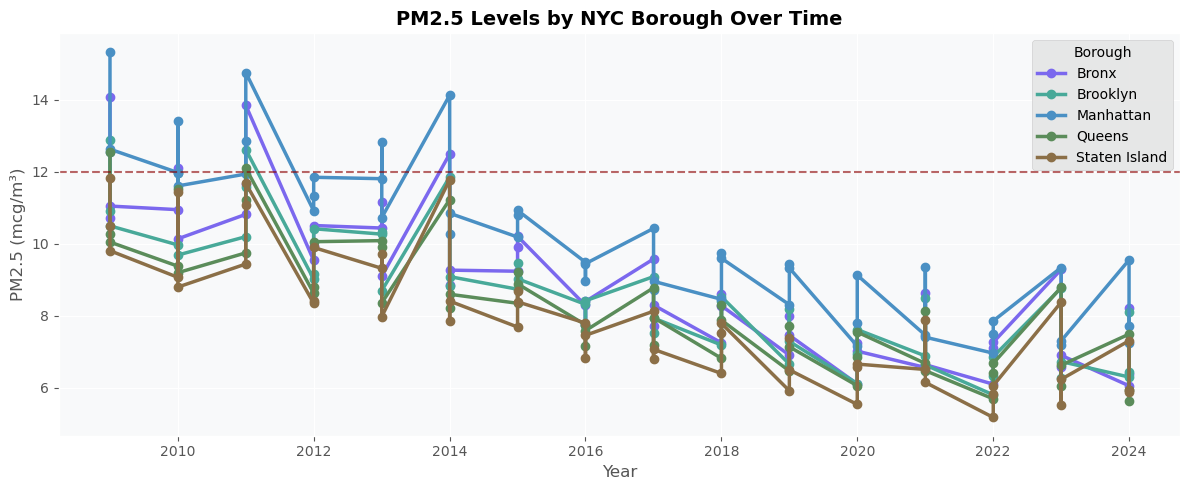

In [16]:
# Pull PM2.5 from raw long-format data
raw = pd.read_csv(RAW_CSV)
raw.columns = [c.strip().lower().replace(' ', '_') for c in raw.columns]
raw['data_value'] = pd.to_numeric(raw['data_value'], errors='coerce')
raw['start_date'] = pd.to_datetime(raw['start_date'], errors='coerce')
raw['year'] = raw['start_date'].dt.year

# Borough-level only
boro = raw[(raw['geo_type_name'] == 'Borough') & 
           (raw['geo_place_name'].isin(NYC_BOROUGHS))].copy()

pm25 = boro[boro['name'] == 'Fine particles (PM 2.5)'].copy()

fig, ax = plt.subplots(figsize=(12, 5))
for borough, group in pm25.groupby('geo_place_name'):
    group_sorted = group.sort_values('start_date')
    ax.plot(group_sorted['start_date'], group_sorted['data_value'],
            marker='o', label=borough, linewidth=2.5,
            color=BOROUGH_COLORS.get(borough, '#4A90C4'))

ax.set_title('PM2.5 Levels by NYC Borough Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('PM2.5 (mcg/m³)')
ax.legend(title='Borough', framealpha=0.9)
ax.axhline(12, color='#8B0000', linestyle='--', alpha=0.6, label='EPA annual standard (12 mcg/m³)')
ax.set_facecolor('#F8F9FA')
plt.tight_layout()
plt.show()

### 4b. Asthma ER Visits vs PM2.5 by Borough

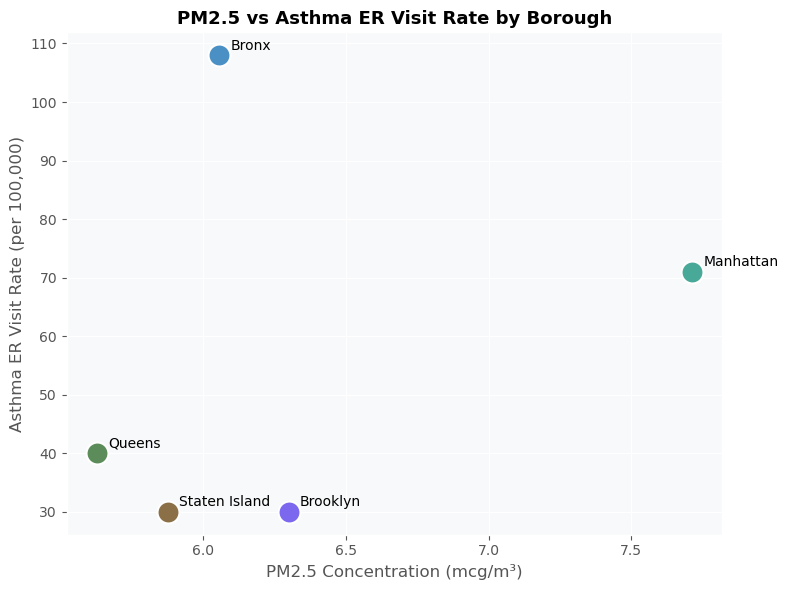

In [17]:
asthma = boro[boro['name'] == 'Asthma emergency department visits due to PM2.5'].copy()
pm25_latest = pm25.sort_values('start_date').groupby('geo_place_name').last().reset_index()
asthma_latest = asthma.sort_values('start_date').groupby('geo_place_name').last().reset_index()

combined = pm25_latest[['geo_place_name', 'data_value']].rename(
    columns={'data_value': 'pm25'})
combined = combined.merge(
    asthma_latest[['geo_place_name', 'data_value']].rename(
        columns={'data_value': 'asthma_er_rate'}),
    on='geo_place_name'
)

fig, ax = plt.subplots(figsize=(8, 6))
for i, row in combined.iterrows():
    ax.scatter(row['pm25'], row['asthma_er_rate'], s=250,
               color=PALETTE[i % len(PALETTE)], zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.annotate(row['geo_place_name'],
                (row['pm25'], row['asthma_er_rate']),
                textcoords='offset points', xytext=(8, 4), fontsize=10)

ax.set_facecolor('#F8F9FA')
ax.set_title('PM2.5 vs Asthma ER Visit Rate by Borough', fontsize=13, fontweight='bold')
ax.set_xlabel('PM2.5 Concentration (mcg/m³)')
ax.set_ylabel('Asthma ER Visit Rate (per 100,000)')
plt.tight_layout()
plt.show()

### 4c. Truck Miles vs Health Outcomes by Borough

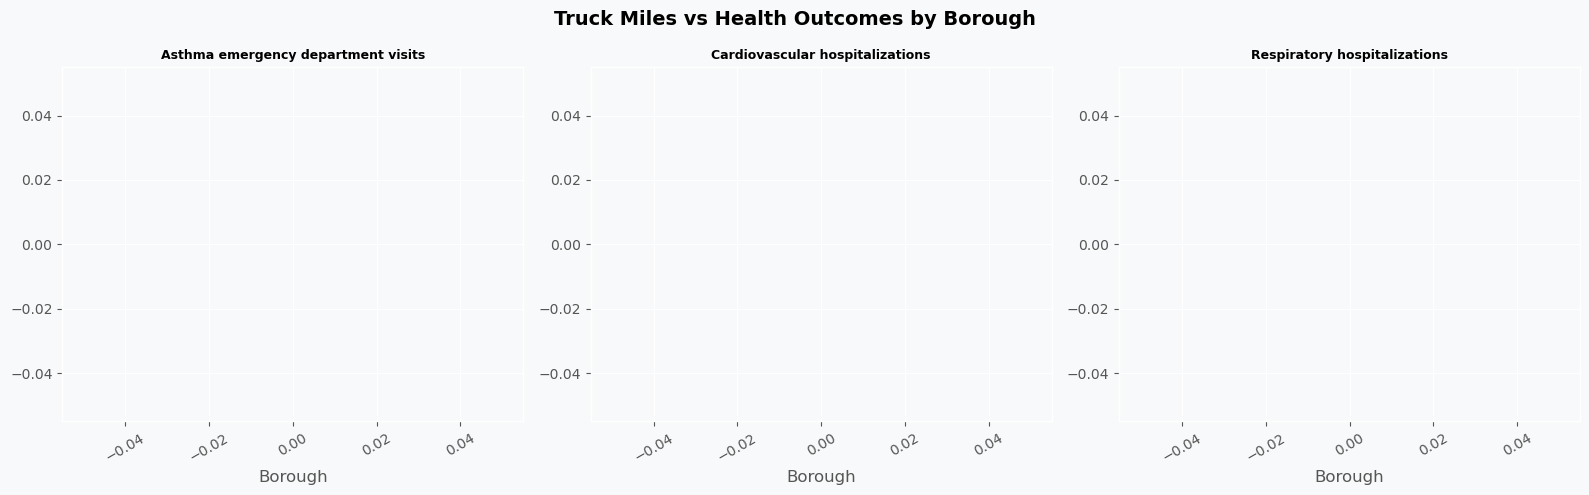

In [18]:
trucks = boro[boro['name'] == 'Annual vehicle miles traveled (trucks)'].copy()

health_indicators = [
    'Asthma emergency department visits due to PM2.5',
    'Cardiovascular hospitalizations due to PM2.5 (age 40+)',
    'Respiratory hospitalizations due to PM2.5 (age 20+)',
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Truck Miles vs Health Outcomes by Borough', fontsize=14, fontweight='bold')
fig.patch.set_facecolor('#F8F9FA')

trucks_avg = trucks.groupby('geo_place_name')['data_value'].mean().reset_index()
trucks_avg.columns = ['borough', 'truck_miles']

for ax, indicator in zip(axes, health_indicators):
    health = boro[boro['name'] == indicator].copy()
    health_avg = health.groupby('geo_place_name')['data_value'].mean().reset_index()
    health_avg.columns = ['borough', 'health_rate']

    merged = trucks_avg.merge(health_avg, on='borough')
    bar_colors = [BOROUGH_COLORS.get(b, '#4A90C4') for b in merged['borough']]

    ax.bar(merged['borough'], merged['health_rate'],
           color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.set_facecolor('#F8F9FA')
    ax.set_title(indicator.split('due to')[0].strip(), fontsize=9, fontweight='bold')
    ax.set_xlabel('Borough')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 4d. Correlation Heatmap

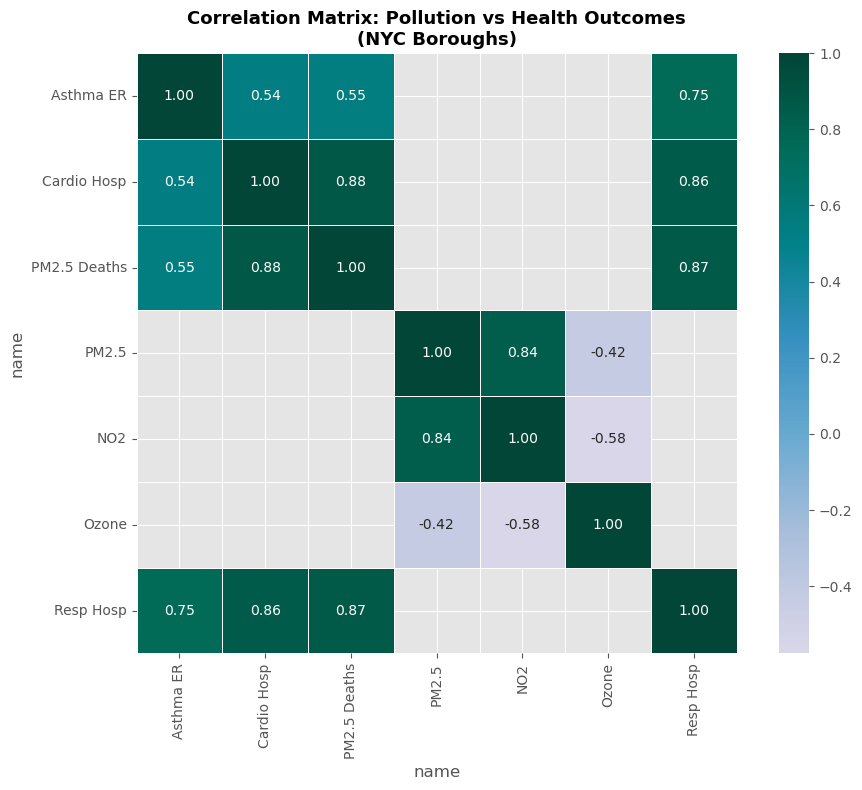

In [19]:
# Build correlation table from long data
indicators_of_interest = [
    'Fine particles (PM 2.5)',
    'Nitrogen dioxide (NO2)',
    'Ozone (O3)',
    'Annual vehicle miles traveled (trucks)',
    'Asthma emergency department visits due to PM2.5',
    'Cardiovascular hospitalizations due to PM2.5 (age 40+)',
    'Respiratory hospitalizations due to PM2.5 (age 20+)',
    'Deaths due to PM2.5',
]

pivot_corr = boro[boro['name'].isin(indicators_of_interest)].pivot_table(
    index=['geo_place_name', 'time_period'],
    columns='name',
    values='data_value',
    aggfunc='mean'
)

# Shorten column names for display
short_names = {
    'Fine particles (PM 2.5)':                              'PM2.5',
    'Nitrogen dioxide (NO2)':                               'NO2',
    'Ozone (O3)':                                           'Ozone',
    'Annual vehicle miles traveled (trucks)':               'Truck Miles',
    'Asthma emergency department visits due to PM2.5':      'Asthma ER',
    'Cardiovascular hospitalizations due to PM2.5 (age 40+)': 'Cardio Hosp',
    'Respiratory hospitalizations due to PM2.5 (age 20+)':  'Resp Hosp',
    'Deaths due to PM2.5':                                  'PM2.5 Deaths',
}
pivot_corr = pivot_corr.rename(columns=short_names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pivot_corr.corr(), annot=True, fmt='.2f', cmap=HEATMAP_CMAP,
            center=0, square=True, ax=ax,
            annot_kws={'size': 10},
            linewidths=0.5, linecolor='white')
ax.set_title('Correlation Matrix: Pollution vs Health Outcomes\n(NYC Boroughs)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4e. Real-Time AQI from AirNow (if available)

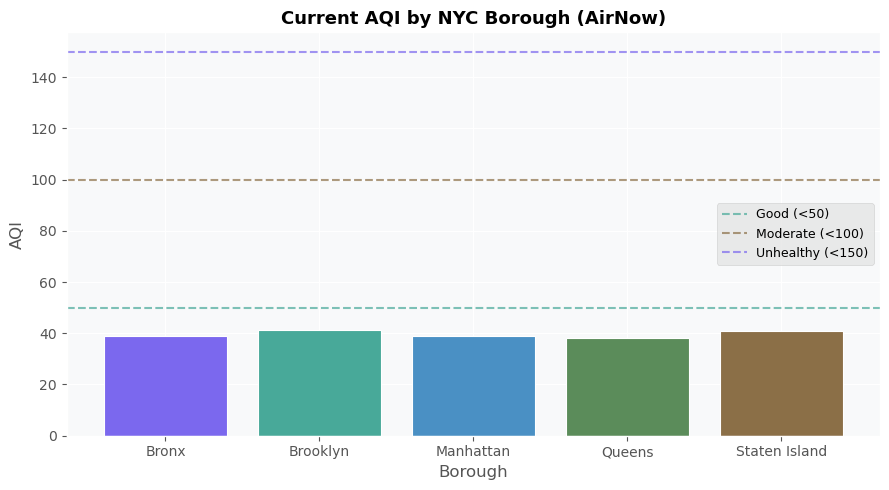

In [20]:
if os.path.exists(AIRNOW_CSV):
    airnow = pd.read_csv(AIRNOW_CSV)
    airnow.columns = [c.lower() for c in airnow.columns]

    if 'aqi' in airnow.columns:
        airnow['aqi'] = pd.to_numeric(airnow['aqi'], errors='coerce')
        boro_aqi = airnow.groupby('borough')['aqi'].mean().reset_index()

        fig, ax = plt.subplots(figsize=(9, 5))
        bar_colors = [BOROUGH_COLORS.get(b, '#4A90C4') for b in boro_aqi['borough']]
        ax.bar(boro_aqi['borough'], boro_aqi['aqi'],
               color=bar_colors, edgecolor='white', linewidth=0.8)
        ax.axhline(50,  color='#48A999', linestyle='--', alpha=0.7, label='Good (<50)')
        ax.axhline(100, color='#8B6F47', linestyle='--', alpha=0.7, label='Moderate (<100)')
        ax.axhline(150, color='#7B68EE', linestyle='--', alpha=0.7, label='Unhealthy (<150)')
        ax.set_facecolor('#F8F9FA')
        ax.set_title('Current AQI by NYC Borough (AirNow)', fontsize=13, fontweight='bold')
        ax.set_xlabel('Borough')
        ax.set_ylabel('AQI')
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()
    else:
        print('AQI column not found in AirNow data')
else:
    print('AirNow CSV not found — run dataingestion.py with a valid API key')

---
## Section 5 — Key Findings

> Fill this in after running the analysis. Use the visualizations above to answer:

1. **Which borough has the highest PM2.5 levels?**
2. **Is there a visible correlation between truck miles and asthma ER visits?**
3. **Which borough has the highest cardiovascular hospitalization rate?**
4. **How does the current AirNow AQI compare to historical averages?**
5. **Has pollution improved over time across boroughs?**

---
## Section 6 — Assignment Answers

**What does your dataset explore?**  
The relationship between air pollution levels (PM2.5, NO2, Ozone, truck traffic) and pollution-related health outcomes (asthma ER visits, cardiovascular hospitalizations, respiratory hospitalizations, deaths) across NYC's 5 boroughs from 2005 to present.

**Dependent variable:**  
Asthma ER visit rate (per 100,000) — Quantitative

**Independent variables (7+):**

| Variable | Type |
|---|---|
| PM2.5 concentration (mcg/m³) | Quantitative |
| NO2 concentration (ppb) | Quantitative |
| Ozone concentration (ppb) | Quantitative |
| Annual truck miles traveled | Quantitative |
| Annual total vehicle miles | Quantitative |
| Current AQI (AirNow) | Quantitative |
| Borough | Categorical |
| Time Period | Categorical |

**Dataset size:** 18,862+ rows (well above the 1,000 row minimum)